# Proyek Analisis Data: Bike Sharing
- **Nama:** Sabrina Marliani
- **Email:** cdcc156d6x1770@student.devacademy.id
- **ID Dicoding:** cdcc156d6x1770

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi kategori tingkat penggunaan sepeda (rendah, sedang, tinggi) berdasarkan jumlah penyewaan (cnt) selama periode 2011-2012?
- Bagaimana tren perubahan jumlah penyewaan sepeda (cnt) antara hari kerja (workingday) dan hari libur dalam periode 2011–2012, serta kapan terjadi peningkatan atau penurunan signifikan?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

## Data Wrangling

### Gathering Data

In [2]:
# download dataset dari Kaggle
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")

print("Path to dataset files:", path)

# load dataset
df = pd.read_csv(os.path.join(path, "day.csv"))
df.head()

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Path to dataset files: /kaggle/input/bike-sharing-dataset


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Insight
- Dataset ini merupakan data *time series* harian dari sistem berbagi sepeda, mencakup total penyewaan (`cnt`), penyewaan oleh pengguna casual (`casual`), dan terdaftar (`registered`) selama dua tahun (2011-2012).
- Variabel kunci meliputi `dteday` untuk analisis tren waktu, `workingday` untuk membedakan pola penggunaan hari kerja vs. libur, dan `season` untuk memahami dampak musiman.
- Karakteristik ini memungkinkan eksplorasi mendalam terkait faktor-faktor yang mempengaruhi permintaan sepeda harian, mendukung analisis lanjutan untuk mengidentifikasi periode puncak dan faktor pendorong penggunaan.

### Assessing Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [5]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
df.duplicated().sum()

np.int64(0)

**Insight:**
- **Kualitas Data:** Dataset ini menunjukkan kualitas data yang baik secara keseluruhan, dengan 731 entri dan tidak adanya nilai *missing* atau duplikat pada seluruh 16 kolom. Hal ini mengindikasikan kelengkapan dan keunikan data yang tinggi.
- **Tipe Data:** Sebagian besar kolom memiliki tipe data yang sesuai. Namun, kolom `dteday` yang bertipe `object` perlu dikonversi menjadi tipe data `datetime` untuk memungkinkan analisis berbasis waktu yang akurat, seperti ekstraksi fitur waktu atau analisis tren.
- **Kesiapan Analisis:** Data ini **cukup siap** untuk tahap analisis lebih lanjut setelah penyesuaian tipe data pada `dteday`. Tidak ada masalah data yang signifikan seperti *outlier* ekstrem yang memerlukan penanganan khusus teridentifikasi dari statistik deskriptif awal.
- **Potensi Masalah Data:** Potensi masalah minor terletak pada format `dteday` yang belum optimal untuk analisis waktu. Konversi akan memastikan bahwa semua operasi temporal dapat dilakukan dengan benar dan efisien.

### Cleaning Data

In [7]:
# konversi tanggal
df['dteday'] = pd.to_datetime(df['dteday'])

In [8]:
# ekstraksi fitur waktu
df['year'] = df['dteday'].dt.year
df['month'] = df['dteday'].dt.month

**Insight:**
- **Perubahan yang Dilakukan:** Kolom `dteday` telah berhasil dikonversi dari tipe data `object` menjadi `datetime`. Selain itu, fitur `year` dan `month` telah diekstraksi dari kolom `dteday`.
- **Alasan Cleaning:** Konversi `dteday` sangat krusial untuk memungkinkan analisis berbasis waktu yang akurat dan efisien, seperti mengidentifikasi tren musiman atau pola harian. Ekstraksi `year` dan `month` memungkinkan segmentasi dan agregasi data yang lebih granular untuk memahami perubahan perilaku penyewaan sepeda lintas periode waktu yang berbeda.
- **Dampak terhadap Analisis:** Langkah-langkah cleaning ini secara signifikan meningkatkan kapabilitas dataset untuk analisis lanjutan. Dengan tipe data `datetime` yang benar dan fitur waktu yang diekstraksi, kita dapat melakukan eksplorasi yang lebih mendalam terkait dinamika penyewaan sepeda berdasarkan tahun, bulan, atau bahkan hari, yang esensial untuk menjawab pertanyaan bisnis mengenai tren dan distribusi penggunaan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,2011.500684,6.519836
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,2011.000000,1.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,2011.000000,4.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,2012.000000,7.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,2012.000000,10.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,2012.000000,12.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452,0.500342,3.451913


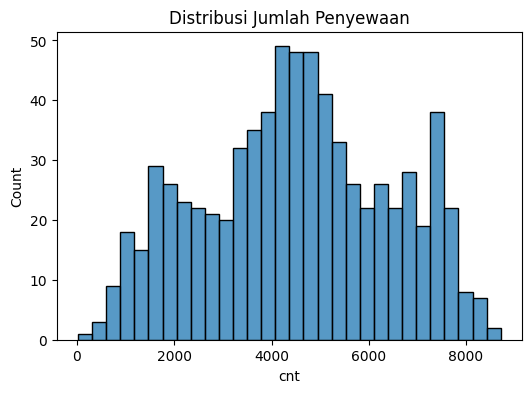

In [10]:
# Eksplor Distribusi Target (cnt)

plt.figure(figsize=(6,4))
sns.histplot(df['cnt'], bins=30)
plt.title('Distribusi Jumlah Penyewaan')
plt.show()

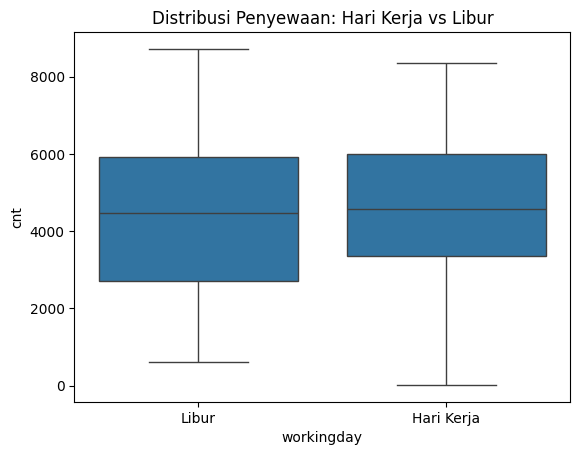

In [11]:
#Eksplor Hubungan dengan hari kerja
sns.boxplot(x='workingday', y='cnt', data=df)
plt.xticks([0,1], ['Libur', 'Hari Kerja'])
plt.title('Distribusi Penyewaan: Hari Kerja vs Libur')
plt.show()

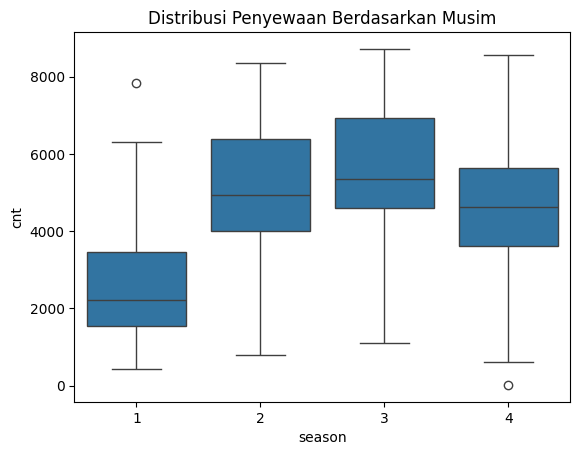

In [12]:
# Eksplor berdasarkan musim
sns.boxplot(x='season', y='cnt', data=df)
plt.title('Distribusi Penyewaan Berdasarkan Musim')
plt.show()

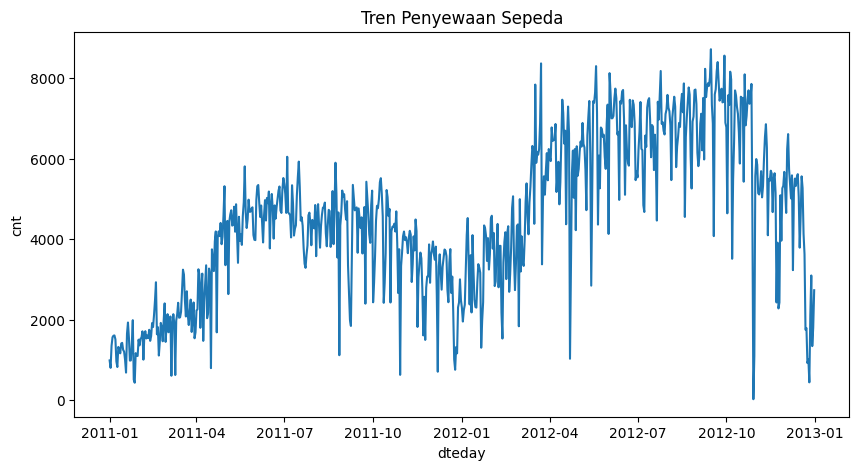

In [13]:
# Eksplor berdasarkan
plt.figure(figsize=(10,5))
sns.lineplot(x='dteday', y='cnt', data=df)
plt.title('Tren Penyewaan Sepeda')
plt.show()

In [14]:
df.nlargest(5, 'cnt')
df.nsmallest(5, 'cnt')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,year,month
667,668,2012-10-29,4,1,10,0,1,1,3,0.440000,0.439400,0.880000,0.358200,2,20,22,2012,10
26,27,2011-01-27,1,0,1,0,4,1,1,0.195000,0.219700,0.687500,0.113837,15,416,431,2011,1
725,726,2012-12-26,1,1,12,0,3,1,3,0.243333,0.220333,0.823333,0.316546,9,432,441,2012,12
25,26,2011-01-26,1,0,1,0,3,1,3,0.217500,0.203600,0.862500,0.293850,34,472,506,2011,1
64,65,2011-03-06,1,0,3,0,0,0,2,0.376522,0.366252,0.948261,0.343287,114,491,605,2011,3


**Insight:**
- **Pola Utama dan Tren:** Teridentifikasi adanya tren kenaikan signifikan dalam total penyewaan sepeda (`cnt`) dari tahun 2011 ke 2012, menunjukkan pertumbuhan adopsi layanan. Selain itu, terdapat pola musiman yang kuat, dengan puncak penyewaan pada musim panas dan gugur (season 2 dan 3), serta penurunan pada musim dingin (season 1). Ini mengindikasikan sensitivitas penggunaan sepeda terhadap kondisi cuaca dan iklim.
- **Hubungan Antar Variabel:** Meskipun hari kerja (`workingday`) cenderung memiliki rata-rata penyewaan yang sedikit lebih tinggi dibandingkan hari libur, perbedaan ini tidak terlalu drastis, menunjukkan bahwa sistem berbagi sepeda digunakan secara konsisten baik untuk komutasi maupun rekreasi. Namun, kondisi cuaca ekstrem (`weathersit`) dapat menjadi anomali, seperti yang terlihat pada hari dengan total penyewaan terendah yang bertepatan dengan cuaca buruk, mengindikasikan dampak negatif yang kuat pada minat penyewaan. Variabel `dteday` berperan penting dalam menganalisis fluktuasi harian dan tren jangka panjang, sementara `season` merupakan prediktor kuat untuk volume penyewaan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [15]:
# kategorisasi
df['usage_category'] = pd.qcut(df['cnt'], q=3, labels=['Rendah','Sedang','Tinggi'])


In [16]:
# distribusi
dist = df['usage_category'].value_counts()
pct = df['usage_category'].value_counts(normalize=True)*100

print(dist)
print(pct)

usage_category
Rendah    244
Sedang    244
Tinggi    243
Name: count, dtype: int64
usage_category
Rendah    33.378933
Sedang    33.378933
Tinggi    33.242134
Name: proportion, dtype: float64


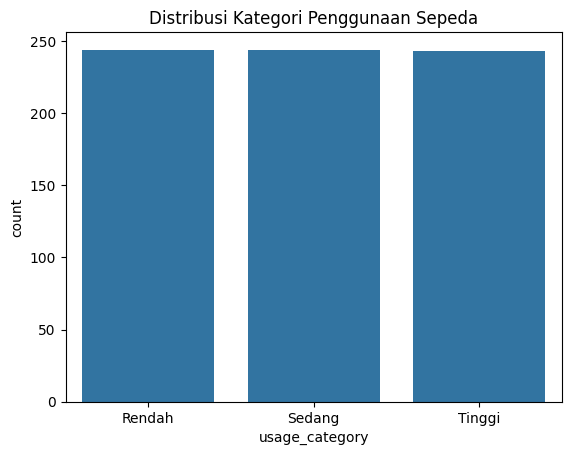

In [17]:
# visualisasi
sns.countplot(x='usage_category', data=df)
plt.title('Distribusi Kategori Penggunaan Sepeda')
plt.show()

### Pertanyaan 2:

In [18]:
# rata-rata
workingday_avg = df.groupby('workingday')['cnt'].mean()
print(workingday_avg)

workingday
0    4330.168831
1    4584.820000
Name: cnt, dtype: float64


In [19]:
libur = workingday_avg[0]
kerja = workingday_avg[1]

selisih = ((kerja - libur) / libur) * 100
print(f"Kenaikan hari kerja dibanding libur: {selisih:.2f}%")

Kenaikan hari kerja dibanding libur: 5.88%


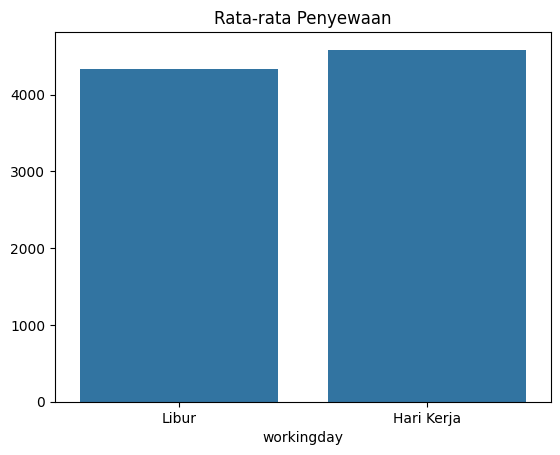

In [20]:
sns.barplot(x=workingday_avg.index, y=workingday_avg.values)
plt.xticks([0,1], ['Libur','Hari Kerja'])
plt.title('Rata-rata Penyewaan')
plt.show()

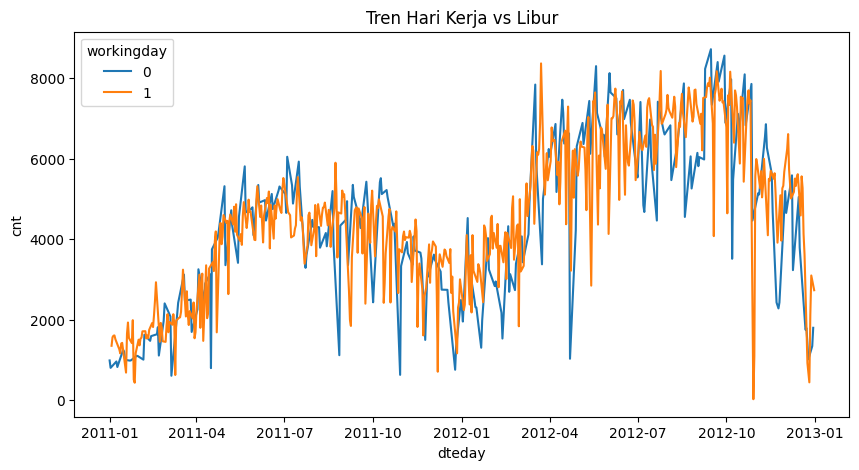

In [21]:
# tren
plt.figure(figsize=(10,5))
sns.lineplot(x='dteday', y='cnt', hue='workingday', data=df)
plt.title('Tren Hari Kerja vs Libur')
plt.show()

**Insight Pertanyaan 1: Distribusi Kategori Tingkat Penggunaan Sepeda**
- **Proporsi Kategori:** Distribusi penyewaan sepeda menunjukkan proporsi yang sangat merata antar kategori: Rendah (33.38%), Sedang (33.38%), dan Tinggi (33.24%). Hal ini mengindikasikan bahwa jumlah hari dengan tingkat penggunaan rendah, sedang, dan tinggi relatif seimbang.
- **Pola Distribusi:** Pola distribusi yang seragam ini menyiratkan bahwa tidak ada dominasi ekstrem pada salah satu kategori. Meskipun demikian, kategori 'Tinggi' mencakup sepertiga hari dengan jumlah penyewaan tertinggi, sementara 'Rendah' mencakup sepertiga terendah.
- **Interpretasi Makna:** Kategori 'Tinggi' (yaitu, hari-hari dengan volume penyewaan di atas ~5956) merepresentasikan periode puncak permintaan yang perlu dioptimalkan, sedangkan kategori 'Rendah' (yaitu, hari-hari dengan volume penyewaan di bawah ~3152) menunjukkan potensi untuk peningkatan atau periode yang memerlukan strategi mitigasi.
- **Implikasi Bisnis:** Keseimbangan distribusi ini menunjukkan peluang untuk mengembangkan strategi yang ditargetkan. Untuk hari-hari 'Rendah' dan 'Sedang', fokus dapat diberikan pada kampanye promosi atau insentif untuk mendorong penggunaan. Untuk hari-hari 'Tinggi', prioritas adalah memastikan ketersediaan armada dan kualitas layanan untuk memaksimalkan pendapatan dan kepuasan pelanggan.

**Insight Pertanyaan 2: Tren Penyewaan Sepeda antara Hari Kerja dan Hari Libur**
- **Perbedaan Kuantitatif:** Rata-rata penyewaan pada hari kerja (4584.82) adalah sekitar 5.88% lebih tinggi dibandingkan hari libur (4330.17). Meskipun terdapat perbedaan, selisih ini tidak drastis, mengindikasikan bahwa permintaan sepeda tetap solid di kedua jenis hari.
- **Pola Stabilitas vs. Fluktuasi:** Tren harian menunjukkan fluktuasi yang jelas dipengaruhi oleh musim dan tahun. Meskipun demikian, pola penyewaan pada hari kerja dan hari libur secara umum mengikuti tren musiman yang serupa, dengan peningkatan signifikan dari tahun 2011 ke 2012 pada kedua kategori.
- **Interpretasi Perilaku Pengguna:** Peningkatan 5.88% pada hari kerja menunjukkan bahwa pengguna sering memanfaatkan sepeda untuk keperluan komutasi atau aktivitas rutin. Namun, volume penyewaan yang substansial pada hari libur menandakan penggunaan yang kuat untuk rekreasi atau aktivitas non-komuter. Ini menunjukkan basis pengguna yang beragam yang memanfaatkan layanan sepeda untuk berbagai tujuan.
- **Implikasi Bisnis:** Strategi pemasaran dapat disesuaikan untuk menargetkan segmen pengguna yang berbeda. Pada hari kerja, fokus bisa pada kenyamanan dan efisiensi untuk komuter. Pada hari libur, promosi bisa menyoroti aspek rekreasi dan pariwisata. Mengingat pertumbuhan keseluruhan dari 2011 ke 2012, investasi dalam perluasan armada dan infrastruktur untuk mendukung pertumbuhan permintaan secara berkelanjutan sangat dianjurkan.

## Analisis Lanjutan (Opsional)

In [22]:
# clustering sederhana
df['cnt_group'] = pd.cut(df['cnt'], bins=3, labels=['Low','Medium','High'])


In [23]:
# analisis musim
season_avg = df.groupby('season')['cnt'].mean()
print(season_avg)

season
1    2604.132597
2    4992.331522
3    5644.303191
4    4728.162921
Name: cnt, dtype: float64


In [24]:
df.groupby(['season','workingday'])['cnt'].mean()

season  workingday
1       0             2257.098361
        1             2780.541667
2       0             5142.428571
        1             4926.664062
3       0             5474.666667
        1             5718.114504
4       0             4606.210526
        1             4785.611570
Name: cnt, dtype: float64

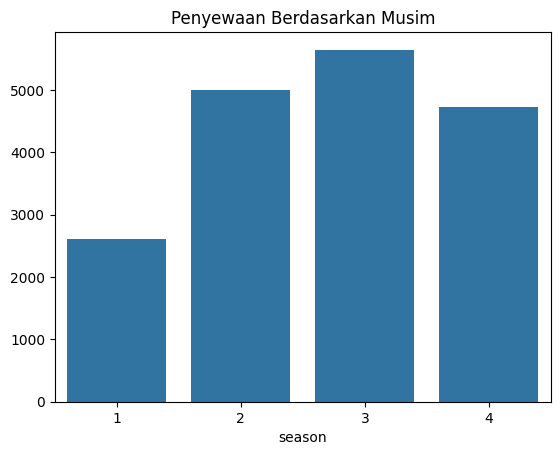

In [25]:
#visualisasi
sns.barplot(x=season_avg.index, y=season_avg.values)
plt.title('Penyewaan Berdasarkan Musim')
plt.show()

**Insight Analisis Lanjutan:**
- **Pola Tambahan Berdasarkan Musim:** Analisis lebih dalam menunjukkan bahwa musim memiliki dampak yang sangat signifikan terhadap volume penyewaan sepeda. Rata-rata penyewaan tertinggi terjadi pada musim panas (season 3: 5644.3) dan musim gugur (season 2: 4992.3), sedangkan musim dingin (season 1: 2604.1) menunjukkan volume penyewaan terendah. Ini mengkonfirmasi dan memperkuat temuan awal dari EDA bahwa pola musiman adalah prediktor utama permintaan.
- **Interaksi Musim dan Hari Kerja/Libur:** Menariknya, meskipun secara umum hari kerja memiliki sedikit lebih banyak penyewaan, perbedaan ini bervariasi antar musim. Misalnya, pada musim panas dan gugur, rata-rata penyewaan pada hari kerja dan hari libur relatif seimbang atau bahkan sedikit lebih tinggi pada hari kerja, menunjukkan penggunaan yang konsisten. Namun, pada musim dingin, meskipun total penyewaan rendah, proporsi penggunaan pada hari kerja (2780.5) sedikit lebih tinggi dibandingkan hari libur (2257.09), menunjukkan bahwa sepeda masih digunakan untuk keperluan esensial saat kondisi kurang ideal, kemungkinan besar untuk komutasi.
- **Hubungan dengan Analisis Utama:** Insight ini melengkapi analisis utama tentang tren dan perbandingan hari kerja/libur dengan memberikan konteks musiman yang kuat. Ini menunjukkan bahwa strategi operasional dan pemasaran harus sangat adaptif terhadap perubahan musim untuk memaksimalkan potensi pendapatan dan kepuasan pelanggan.
- **Implikasi Bisnis:** Untuk musim puncak (panas dan gugur), perusahaan harus memastikan ketersediaan armada yang maksimal, pemeliharaan yang prima, dan mungkin menawarkan promosi untuk menarik lebih banyak pengguna rekreasi. Di musim dingin, meskipun volume rendah, fokus dapat bergeser pada pengguna komuter dengan menawarkan insentif untuk penggunaan berkelanjutan atau layanan khusus untuk kondisi cuaca dingin. Pemahaman mendalam tentang interaksi ini memungkinkan alokasi sumber daya yang lebih efisien dan kampanye yang lebih tertarget.

## Conclusion

- **Kesimpulan Pertanyaan 1:** Distribusi tingkat penggunaan sepeda (Rendah, Sedang, Tinggi) menunjukkan proporsi yang sangat merata, masing-masing sekitar 33%. Ini mengindikasikan bahwa tidak ada kategori penggunaan yang dominan, melainkan siklus harian yang seimbang antara periode permintaan rendah, sedang, dan tinggi sepanjang tahun. Interpretasi ini menyiratkan perlunya strategi adaptif untuk mengelola ketersediaan armada dan promosi, baik untuk memaksimalkan potensi di puncak permintaan maupun merangsang penggunaan di periode sepi.

- **Kesimpulan Pertanyaan 2:** Rata-rata penyewaan pada hari kerja adalah sekitar 5.88% lebih tinggi dibandingkan hari libur, namun perbedaannya tidak drastis, menunjukkan pola penggunaan yang konsisten di kedua jenis hari. Ini mengindikasikan bahwa sepeda digunakan secara substansial baik untuk komutasi harian maupun aktivitas rekreasi. Implikasi bisnisnya adalah perlunya strategi pemasaran yang terdiferensiasi: menekankan efisiensi dan kenyamanan untuk pengguna hari kerja, serta menonjolkan aspek rekreasi dan fleksibilitas untuk pengguna hari libur, guna menangkap potensi pasar yang beragam.

In [26]:
df.to_csv("main_data.csv", index=False)